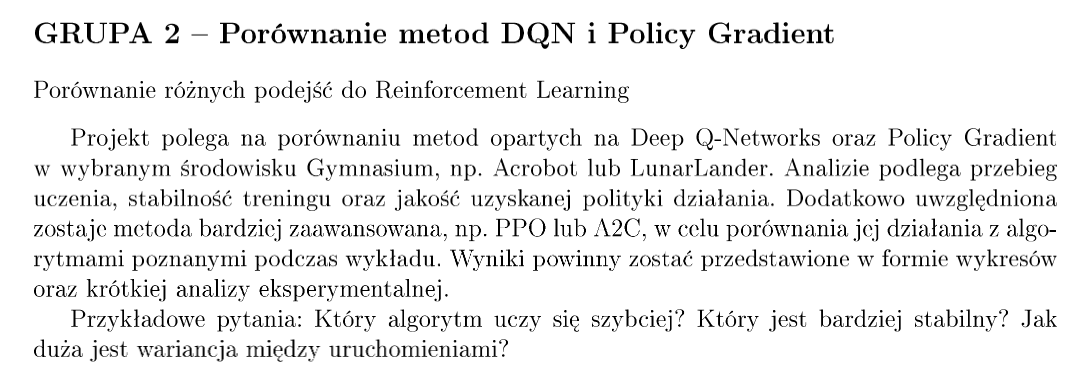

# Wprowadzenie (Reinforcement Learning, nasz temat projektu itd.)

W tym projekcie pod lupę bierzemy reinforcement learning. Szczegóły można przeczytać na [polskiej Wikipedii](https://pl.wikipedia.org/wiki/Uczenie_przez_wzmacnianie), rzecz sprowadza się do tego, że mamy agenta AI i środowisko (np. grę). Agent w środowisku ma swoją politykę (np. prawdopodobieństwo zrobienia kroku w danym kierunku) i kierując się nią, wykonuje akcje, za które otrzymuje określone nagrody. Jego celem jest zmaksymalizowanie nagród.

Najpierw wstępnie zbiera on informacje, a potem działa w pętli:
* zbiera informacje,
* uczy się,
* ewaluuje to, czego się nauczył.


## Nasz projekt
Tematem naszego projektu jest „porównanie metod DQN i Policy Gradient”.

DQN, czyli Deep Q-Networks, to połączenie sieci neuronowych i Q-learningu. Q-learning polega na tym, że dla każdej pary stan-akcja zostaje przyporządkowana Q-wartość nagrody. Celem sieci jest jak najlepsze oszacowanie wartości nagród za wykonanie danej akcji w danym stanie. W zwykłym Q-learningu mamy Q-tabelę przechowującą te wartości, co powoduje, że zwykły Q-learning jest dość słaby do sytuacji, gdy mamy dużo decyzji do podjęcia. Lepiej wtedy się sprawdza DQN, bo do estymacji Q-wartości używamy sieci neuronowych i nie trzeba mieć Q-tabeli.

W Policy Gradient natomiast działamy bardziej bezpośrednio na politykę agenta. Dajmy na to, że wykonujemy daną symulację. Jeśli całość zakończyła się sukcesem, wtedy mówimy: „zwiększ prawdopodobieństwo wykonania każdego ruchu, który był w tym epizodzie”. Jeśli za to symulacja zakończyła się porażką, mówimy: „zmniejsz to prawdopodobieństwo”.

# Gymnasium i Lunar Lander
[Gymnasium](https://gymnasium.farama.org/) jest forkiem biblioteki Gym od OpenAI i służy do zadań reinforcement learningu. My wykorzystamy do naszego zadania Lunar Landera, czyli środowisko, w którym uczymy rakietę lądować. Jest to środowisko Box2d. Poniżej przedstawię najważniejsze parametry Lunar Landera.

## Przestrzeń akcji
Mamy możliwość wykonania 4 konkretnych akcji:
* 0 – nie rób nic,
* 1 – odpal lewy silnik,
* 2 – odpal główny silnik,
* 3 – odpal prawy silnik.

## Przestrzeń obserwacji
Ta przestrzeń odpowiada za opis naszego lądownika. Jest to 8-wymiarowy wektor, który zawiera:
* koordynaty x i y,
* prędkości liniowe x i y,
* kąt nachylenia,
* prędkość kątową,
* booleany informujące, czy każda z nóg naszej rakiety styka się z podłożem, czy nie.

## Nagrody
Punkty są przyznawane po każdym kroku, następująco:
* zwiększane, gdy jesteśmy bliżej lądu, zmniejszane, gdy się oddalamy,
* zwiększane, gdy rakieta porusza się wolnej, zmniejszane, gdy szybciej,
* zmniejszane, jeśli za bardzo się obróciliśmy,
* zwiększane o 10 punktów za każdą nogę, która jest na ziemi,
* zmniejszane o 0,03 punkta, gdy włączamy boczne silniki,
* zmniejszane o 0,3 punkta, gdy włączamy główny silnik,
* jeśli bezpiecznie wyląduje, mamy +100 punktów, w przeciwnym razie -100 punktów.

Dany epizod uznajemy za rozwiązanie, jeśli zdobędzie przynajmniej 200 punktów.

## Start i koniec
Zaczynamy na samej górze na środku. Epizod zostaje przerwany, jeśli lądownik się rozbije, wyjdzie poza kadr albo nie jest przebudzony (tzn. nie rusza się i nie zderza się z innym ciałem).

Oczywiście jest mnóstwo parametrów i argumentów, ale rozpatrzymy je później.

# Przykład
Pokażemy przykład zachowania niewytrenowanego Lunar Landera, żeby było widać, z czym właściwie pracujemy.

In [ ]:
!pip install gymnasium stable-baselines3 moviepy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 24.9 MB/s eta 0:00:00


In [ ]:
!pip install gymnasium[box2d]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 31.9 MB/s eta 0:00:00


In [ ]:
### importy
import gymnasium as gym #gymnasium
from gymnasium.wrappers import RecordVideo #do nagrywania filmików
from stable_baselines3 import DQN # DQN
from stable_baselines3 import PPO # PPO
#do wyświetlania filmików
import os
from IPython.display import Video
import itertools
import pandas as pd
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Tworzenie środowiska z zapisem wideo do folderu "lunar_lander_videos"
env = gym.make("LunarLander-v3", render_mode="rgb_array") # render mode ten umożliwia zapisanie do filmiku
env = RecordVideo(env, video_folder="lunar_lander_videos", episode_trigger=lambda ep: True) # opakowujemy całość w RecordVideo i mówimy, żeby zapisał każdy epizod

# Prosta pętla z losowymi ruchami agenta
observation, info = env.reset() # resetujemy
done = False

while not done:
    action = env.action_space.sample()  # Losowe odpalanie silników
    observation, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

# Zamknięcie środowiska zapisuje plik MP4 na dysku Colaba
env.close()
print("Film został pomyślnie wygenerowany!")

Film został pomyślnie wygenerowany!


In [ ]:
### wyświetlanie filmiku
# 1. Znajdź folder, do którego zapisaliśmy film
video_dir = "lunar_lander_videos"

# 2. Wyciągnij listę plików i odfiltruj tylko te z rozszerzeniem .mp4
mp4_files = [f for f in os.listdir(video_dir) if f.endswith('.mp4')]

if mp4_files:
    # Wybieramy pierwszy znaleziony film (lub najnowszy)
    video_path = os.path.join(video_dir, mp4_files[0])
    print(f"Odtwarzam plik: {video_path}")

    # 3. Wyświetlenie odtwarzacza wideo w Colabie
    display(Video(video_path, embed=True, width=600))
else:
    print("Nie znaleziono żadnego pliku MP4 w wskazanym folderze.")

Odtwarzam plik: lunar_lander_videos/rl-video-episode-0.mp4


# Przykładowe kody
Na razie pokażę najbardziej podstawowe kody treningów DQN i Policy Gradient. Wykorzystują one bibliotekę stable-baselines, która właśnie zawiera gotowe implementacje tych dwóch typów reinforcement learningu.

## DQN

In [ ]:
### PRZYKŁADOWY KOD DQN
# Tworzenie środowiska do TRENINGU (bez nagrywania, żeby było szybciej)
train_env = gym.make("LunarLander-v3")

# Inicjalizacja algorytmu DQN (Deep Q-Learning)
# 'MlpPolicy' to standardowa, gęsta sieć neuronowa (Multi-Layer Perceptron)
model = DQN(
    "MlpPolicy",
    train_env,
    verbose=1,           # Pokazuje statystyki treningu w konsoli
    learning_rate=1e-3,  # Szybkość uczenia sieci
    buffer_size=50000,   # Pamięć powtórek (Replay Buffer)
    exploration_fraction=0.1, # Przez pierwsze 10% czasu agent mocno eksperymentuje
    exploration_final_eps=0.05 # Ostateczny poziom losowości ruchów
)

# Rozpoczęcie procesu uczenia (trening)
print("Rozpoczynam trenowanie sieci neuronowej (DQN)...")
model.learn(total_timesteps=50000) # tu zamiast epok trenujemy łącznie na krokach epizodów (na początku epizody mogą być bardzo krótkie)
print("Trening zakończony!")

# Tworzenie NOWEGO środowiska z Wrapperem do nagrania efektu końcowego
test_env = gym.make("LunarLander-v3", render_mode="rgb_array")
test_env = RecordVideo(test_env, video_folder="dqn_lunar_lander", episode_trigger=lambda ep: True)

# Testowanie nauczonego agenta (1 epizod na wideo)
obs, info = test_env.reset()
done = False

while not done:
    # Model DQN podejmuje decyzję (predict) na podstawie obserwacji
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = test_env.step(action)
    done = terminated or truncated

test_env.close()
print("Wideo z nauczonym agentem zostało wygenerowane!")

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute
/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Rozpoczynam trenowanie sieci neuronowej (DQN)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 87.2     |
|    ep_rew_mean      | -183     |
|    exploration_rate | 0.934    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 677      |
|    time_elapsed     | 0        |
|    total_timesteps  | 349      |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 3.68     |
|    n_updates        | 62       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 103      |
|    ep_rew_mean      | -148     |
|    exploration_rate | 0.844    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 878      |
|    time_elapsed     | 0        |
|    total_timesteps  | 823      |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 1.06     |
|    n_updates      

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Wideo z nauczonym agentem zostało wygenerowane!


In [ ]:
### wyświetlenie filmiku DQN
# Ścieżka do folderu z filmem DQN
video_dir = "dqn_lunar_lander"

# Pobranie listy plików .mp4
mp4_files = [f for f in os.listdir(video_dir) if f.endswith('.mp4')]

if mp4_files:
    # Wybieramy plik wideo
    video_path = os.path.join(video_dir, mp4_files[0])
    print(f"Odtwarzam przejazd wytrenowanego agenta DQN: {video_path}")

    # Wyświetlenie odtwarzacza
    display(Video(video_path, embed=True, width=600))
else:
    print("Nie znaleziono pliku wideo. Upewnij się, że komórka z treningiem DQN wykonała się do końca.")

## Dokładniejszy trening DQN

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

# 1. Przygotowanie folderu na logi
log_dir = "./logs_dqn_eval/"
os.makedirs(log_dir, exist_ok=True)

# 2. Tworzenie środowisk
env = gym.make("LunarLander-v3")
env = Monitor(env, log_dir)  # Wrapper do logowania danych

eval_env = gym.make("LunarLander-v3")

# 3. Konfiguracja EvalCallback
# Będzie testować agenta co 5000 kroków (eval_freq)
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=log_dir,
    log_path=log_dir,
    eval_freq=5000,
    deterministic=True,
    render=False
)

# 4. Trening modelu z wykorzystaniem callbacku
model = DQN("MlpPolicy",
            env,
            learning_rate=0.001,
            batch_size=4,
            exploration_fraction=0.1,
            exploration_final_eps=0.05,
            verbose=0)

print("Rozpoczynam trening z monitorowaniem wyników...")
model.learn(total_timesteps=200000, callback=eval_callback)
print("Trening zakończony!")

Rozpoczynam trening z monitorowaniem wyników...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Eval num_timesteps=5000, episode_reward=-274.58 +/- 119.82
Episode length: 674.60 +/- 382.24
New best mean reward!
Eval num_timesteps=10000, episode_reward=-366.08 +/- 188.09
Episode length: 362.00 +/- 320.39
Eval num_timesteps=15000, episode_reward=-172.41 +/- 94.78
Episode length: 289.40 +/- 51.27
New best mean reward!
Eval num_timesteps=20000, episode_reward=-271.86 +/- 86.14
Episode length: 280.60 +/- 138.20
Eval num_timesteps=25000, episode_reward=-237.52 +/- 125.35
Episode length: 474.20 +/- 147.48
Eval num_timesteps=30000, episode_reward=-244.84 +/- 104.59
Episode length: 519.40 +/- 288.43
Eval num_timesteps=35000, episode_reward=-173.73 +/- 119.63
Episode length: 700.00 +/- 255.11
Eval num_timesteps=40000, episode_reward=-139.98 +/- 121.53
Episode length: 915.80 +/- 168.40
New best mean reward!
Eval num_timesteps=45000, episode_reward=-108.65 +/- 21.69
Episode length: 1000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=50000, episode_reward=-124.18 +/- 44.29
Episode lengt

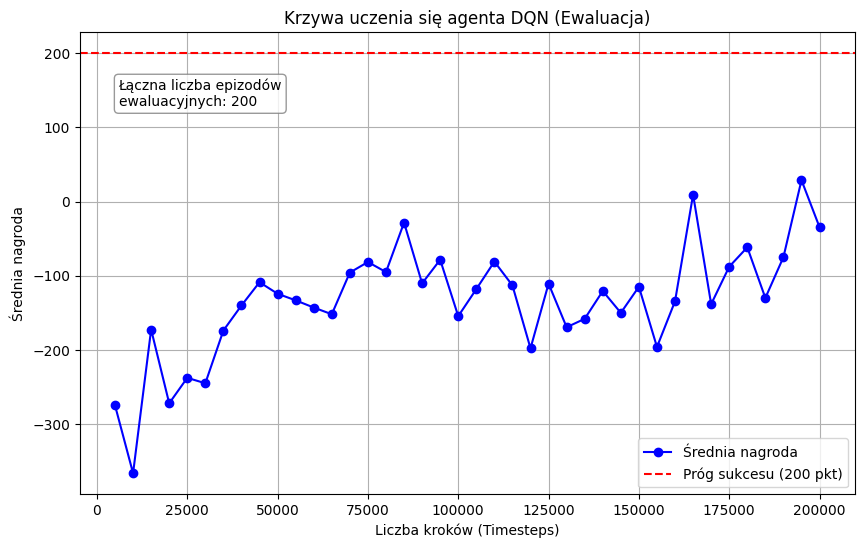

In [ ]:
### Generowanie wykresu nagród z ramką informacyjną
# Ładowanie wyników z pliku wygenerowanego przez EvalCallback
data = np.load(os.path.join(log_dir, "evaluations.npz"))
timesteps = data['timesteps']
results = data['results']

# Obliczamy statystyki
mean_rewards = np.mean(results, axis=1)
total_eval_episodes = results.size

plt.figure(figsize=(10, 6))
plt.plot(timesteps, mean_rewards, marker='o', linestyle='-', color='b', label='Średnia nagroda')
plt.axhline(y=200, color='r', linestyle='--', label='Próg sukcesu (200 pkt)')

# Dodanie ramki informacyjnej (prostokąta) z liczbą epizodów
info_text = f"Łączna liczba epizodów\newaluacyjnych: {total_eval_episodes}"
plt.text(0.05, 0.90, info_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.title("Krzywa uczenia się agenta DQN (Ewaluacja)")
plt.xlabel("Liczba kroków (Timesteps)")
plt.ylabel("Średnia nagroda")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#Fine-Tuning



# Przetestujemy wpływ szybkości uczenia `learning_rate` oraz rozmiaru paczki danych `batch_size` na wyniki agenta DQN.

In [ ]:

# Definiujemy możliwe wartości parametrów
learning_rates = [0.01,0.001,0.0001]
batch_sizes = [2,4,8,16,32,64]

comparison_results = {}

# Generujemy wszystkie kombinacje za pomocą itertools.product
for lr, batch_size in itertools.product(learning_rates, batch_sizes):
    config_name = f"LR={lr}, B={batch_size}"
    print(f"--- Testuję konfigurację: {config_name} ---")

    # Folder na logi
    current_log_dir = f"./logs_tuning_{lr}_{batch_size}/"
    os.makedirs(current_log_dir, exist_ok=True)

    test_env_tuning = Monitor(gym.make("LunarLander-v3"), current_log_dir)
    eval_env_tuning = gym.make("LunarLander-v3")

    eval_cb = EvalCallback(
        eval_env_tuning,
        log_path=current_log_dir,
        eval_freq=2500,
        deterministic=True
    )

    tuning_model = DQN(
        "MlpPolicy",
        test_env_tuning,
        learning_rate=lr,
        batch_size=batch_size,
        verbose=0
    )

    tuning_model.learn(total_timesteps=50000, callback=eval_cb)

    # Pobranie i zapisanie wyników
    data = np.load(os.path.join(current_log_dir, "evaluations.npz"))
    comparison_results[config_name] = {
        "timesteps": data['timesteps'],
        "rewards": np.mean(data['results'], axis=1)
    }

print("Wszystkie testy zakończone pomyślnie!")

--- Testuję konfigurację: LR=0.01, B=2 ---
Eval num_timesteps=2500, episode_reward=-233.75 +/- 9.11
Episode length: 309.00 +/- 53.23
New best mean reward!
Eval num_timesteps=5000, episode_reward=-436.31 +/- 103.69
Episode length: 123.60 +/- 29.59
Eval num_timesteps=7500, episode_reward=-129.74 +/- 190.88
Episode length: 544.60 +/- 357.33
New best mean reward!
Eval num_timesteps=10000, episode_reward=141.15 +/- 45.43
Episode length: 561.80 +/- 231.86
New best mean reward!
Eval num_timesteps=12500, episode_reward=-359.87 +/- 18.98
Episode length: 1000.00 +/- 0.00
Eval num_timesteps=15000, episode_reward=-165.77 +/- 66.86
Episode length: 212.40 +/- 61.34
Eval num_timesteps=17500, episode_reward=-340.56 +/- 55.40
Episode length: 260.00 +/- 49.99
Eval num_timesteps=20000, episode_reward=-202.74 +/- 93.06
Episode length: 376.80 +/- 56.01
Eval num_timesteps=22500, episode_reward=-141.99 +/- 63.14
Episode length: 397.00 +/- 122.84
Eval num_timesteps=25000, episode_reward=-330.88 +/- 127.42
Epi

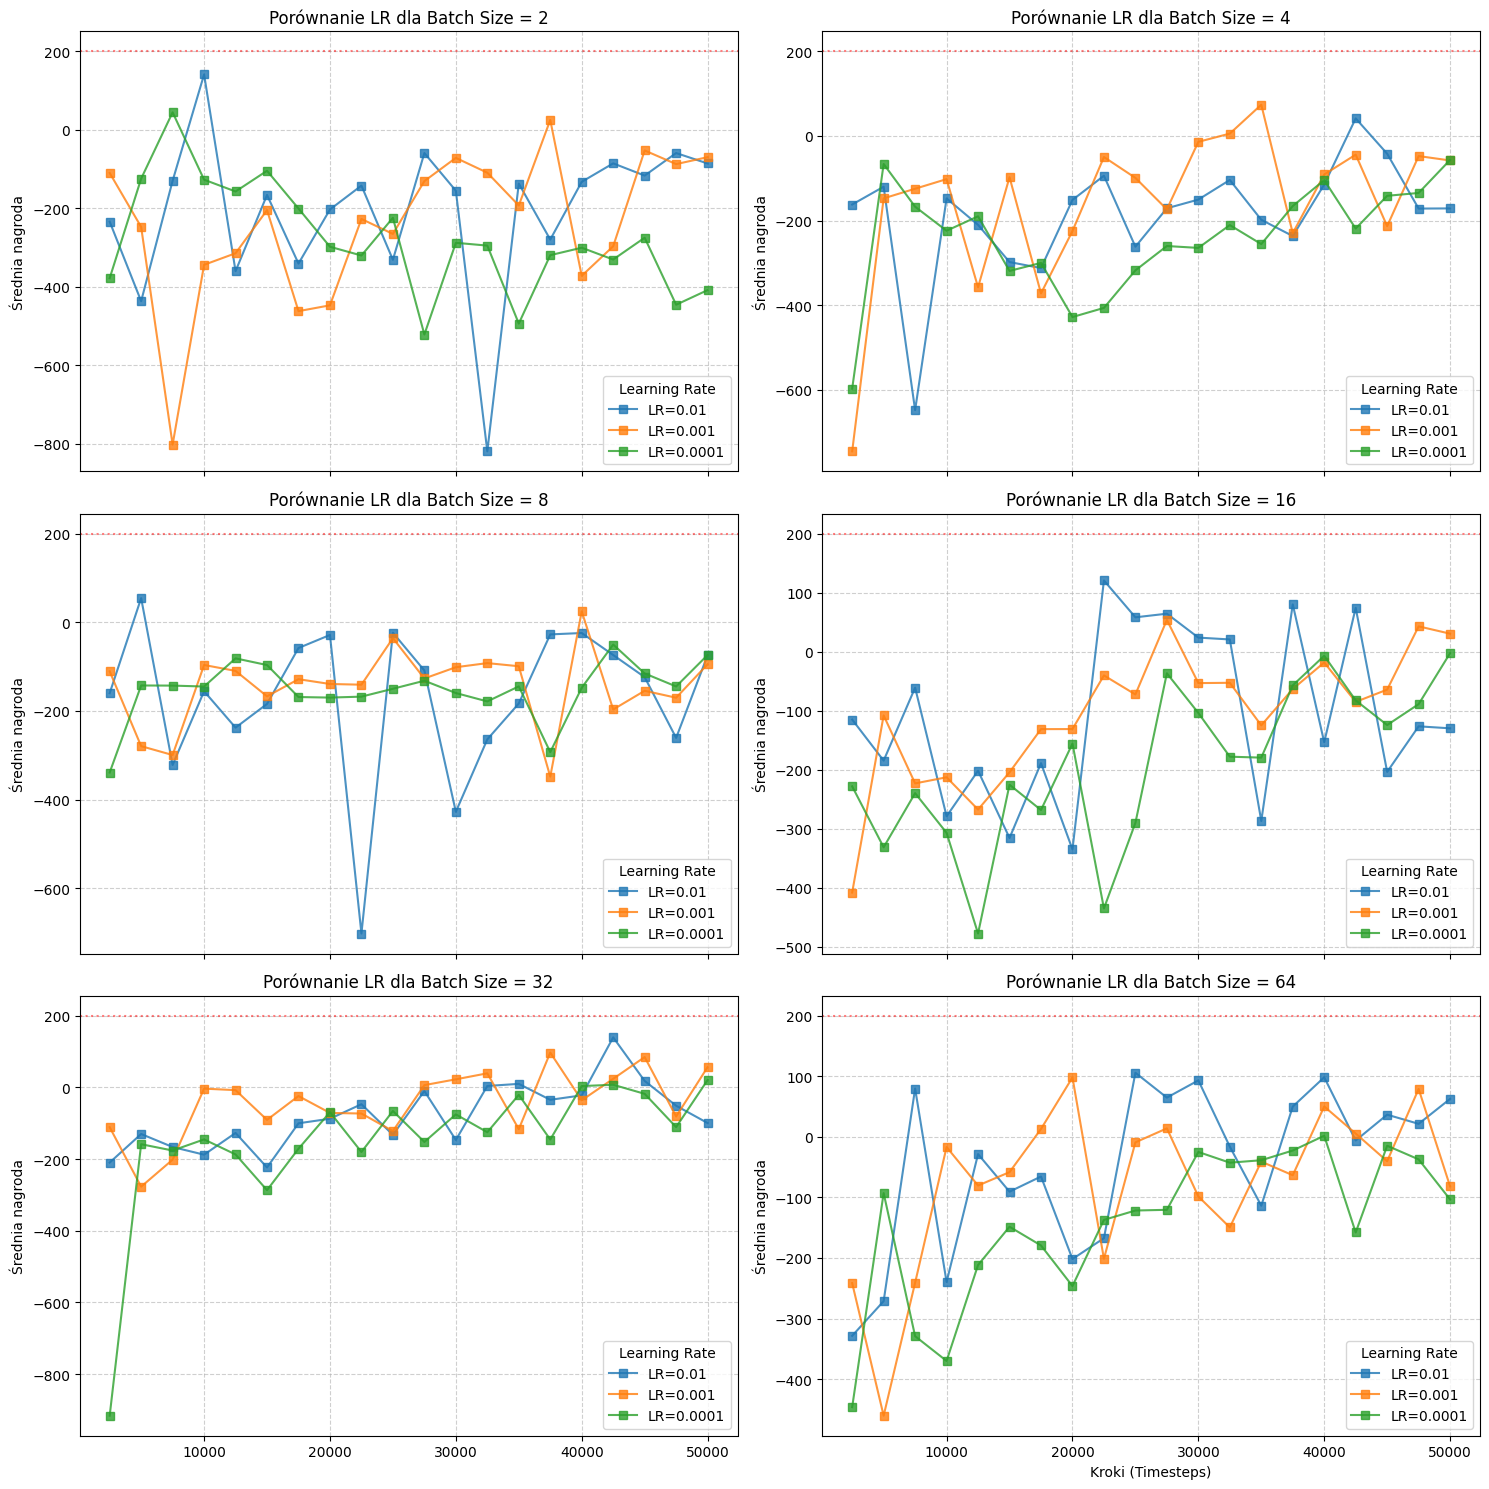

In [ ]:
import matplotlib.pyplot as plt

# Pobieramy unikalne rozmiary batchy
unique_batches = sorted(list(set(bs for lr, bs in [tuple(map(float, k.replace('LR=', '').replace(' B=', '').split(','))) for k in comparison_results.keys()])))

# Tworzymy siatkę wykresów (2 kolumny dla oszczędności miejsca)
cols = 2
rows = (len(unique_batches) + 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows), sharex=True)
axes = axes.flatten()

for i, target_bs in enumerate(unique_batches):
    ax = axes[i]
    for config_name, res in comparison_results.items():
        if f"B={int(target_bs)}" in config_name or f"B={target_bs}" in config_name:
            # Wyciągamy LR z nazwy do legendy
            lr_label = config_name.split(", ")[0]
            ax.plot(res['timesteps'], res['rewards'], label=lr_label, marker='s', alpha=0.8)

    ax.set_title(f"Porównanie LR dla Batch Size = {int(target_bs)}")
    ax.set_ylabel("Średnia nagroda")
    ax.legend(title="Learning Rate", loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.axhline(y=200, color='r', linestyle=':', alpha=0.5)

# Usuwamy puste osie, jeśli liczba wykresów jest nieparzysta
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.xlabel("Kroki (Timesteps)")
plt.tight_layout()
plt.show()

# Optymalizacja gamma i tau

In [ ]:


# Najlepsze parametry z poprzedniego etapu
NAJLEPSZY_LR = 0.001
NAJLEPSZY_BATCH = 32

# Parametry do nowego testu (Fine-tuning Gamma i Tau)
wartosci_gamma = [0.95, 0.98, 0.99, 0.999]
wartosci_tau = [0.001, 0.005, 0.01, 0.05]

wyniki_nowego_tuningu = {}

# Pętla testująca kombinacje Gamma i Tau
for g, t in itertools.product(wartosci_gamma, wartosci_tau):
    nazwa_konfiguracji = f"Gamma={g}, Tau={t}"
    print(f"--- Analizuję: {nazwa_konfiguracji} ---")

    sciezka_logow = f"./logi_nowy_tuning_{g}_{t}/"
    os.makedirs(sciezka_logow, exist_ok=True)

    srodowisko_treningowe = Monitor(gym.make("LunarLander-v3"), sciezka_logow)
    srodowisko_ewaluacyjne = gym.make("LunarLander-v3")

    callback_ewaluacji = EvalCallback(
        srodowisko_ewaluacyjne,
        log_path=sciezka_logow,
        eval_freq=5000,
        deterministic=True,
        verbose=0
    )

    model_dqn = DQN(
        "MlpPolicy",
        srodowisko_treningowe,
        gamma=g,
        tau=t,
        learning_rate=NAJLEPSZY_LR,
        batch_size=NAJLEPSZY_BATCH,
        verbose=0
    )

    # Trening (50 000 kroków dla porównywalności)
    model_dqn.learn(total_timesteps=100000, callback=callback_ewaluacji)

    # Wczytanie wyników
    dane = np.load(os.path.join(sciezka_logow, "evaluations.npz"))
    wyniki_nowego_tuningu[nazwa_konfiguracji] = {
        "kroki": dane['timesteps'],
        "srednie_nagrody": np.mean(dane['results'], axis=1)
    }

print("Nowy fine-tuning zakończony!")

--- Analizuję: Gamma=0.95, Tau=0.001 ---
--- Analizuję: Gamma=0.95, Tau=0.005 ---
--- Analizuję: Gamma=0.95, Tau=0.01 ---
--- Analizuję: Gamma=0.95, Tau=0.05 ---
--- Analizuję: Gamma=0.98, Tau=0.001 ---
--- Analizuję: Gamma=0.98, Tau=0.005 ---
--- Analizuję: Gamma=0.98, Tau=0.01 ---
--- Analizuję: Gamma=0.98, Tau=0.05 ---
--- Analizuję: Gamma=0.99, Tau=0.001 ---
--- Analizuję: Gamma=0.99, Tau=0.005 ---
--- Analizuję: Gamma=0.99, Tau=0.01 ---
--- Analizuję: Gamma=0.99, Tau=0.05 ---
--- Analizuję: Gamma=0.999, Tau=0.001 ---
--- Analizuję: Gamma=0.999, Tau=0.005 ---
--- Analizuję: Gamma=0.999, Tau=0.01 ---
--- Analizuję: Gamma=0.999, Tau=0.05 ---
Nowy fine-tuning zakończony!


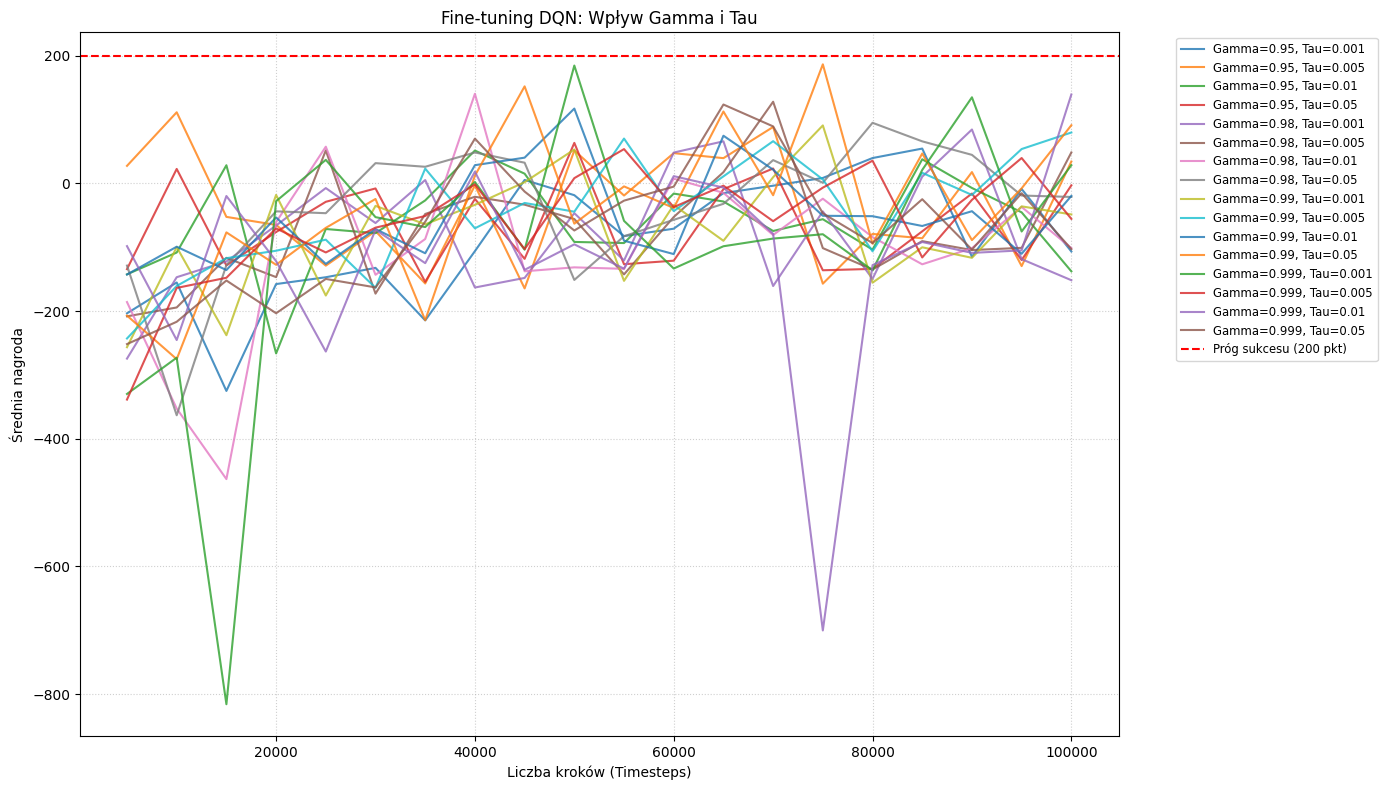

In [ ]:
### Wizualizacja wyników nowego fine-tuningu (Gamma i Tau)
plt.figure(figsize=(14, 8))

for nazwa, dane in wyniki_nowego_tuningu.items():
    plt.plot(dane['kroki'], dane['srednie_nagrody'], label=nazwa, linewidth=1.5, alpha=0.8)

plt.title("Fine-tuning DQN: Wpływ Gamma i Tau")
plt.xlabel("Liczba kroków (Timesteps)")
plt.ylabel("Średnia nagroda")
plt.axhline(y=200, color='red', linestyle='--', label='Próg sukcesu (200 pkt)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

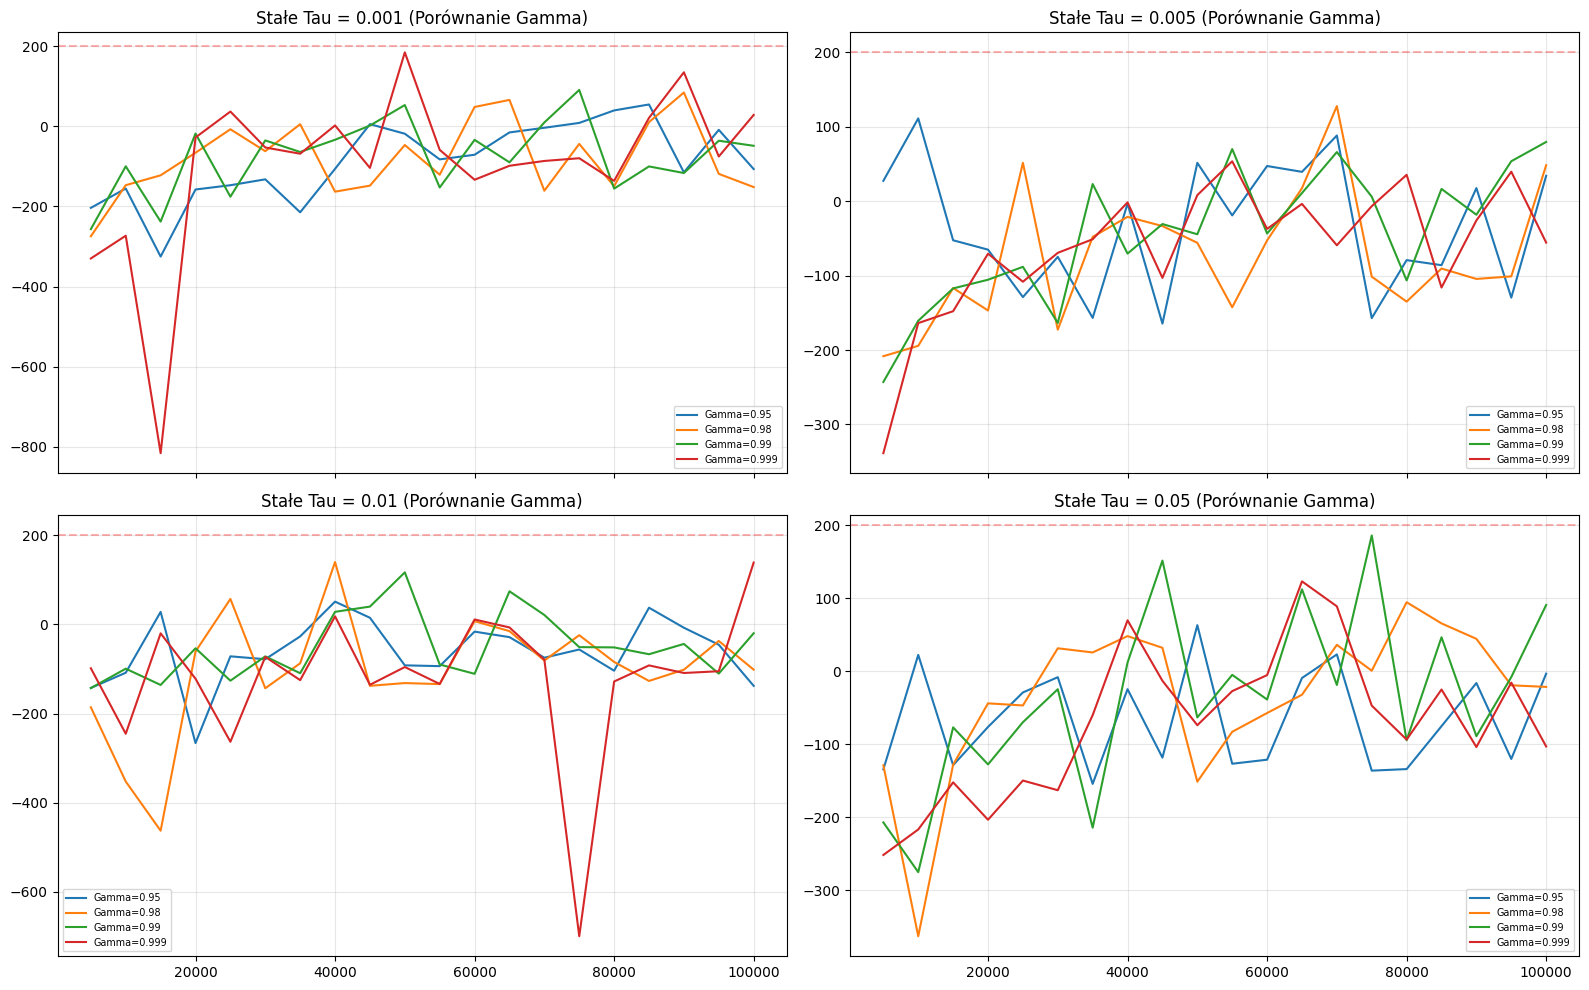

In [ ]:
### Porównanie wpływu Gamma dla poszczególnych wartości Tau
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for i, t_cel in enumerate(wartosci_tau):
    ax = axes[i]
    for nazwa, dane in wyniki_nowego_tuningu.items():
        if f"Tau={t_cel}" in nazwa:
            gamma_val = nazwa.split(", ")[0]
            ax.plot(dane['kroki'], dane['srednie_nagrody'], label=gamma_val)

    ax.set_title(f"Stałe Tau = {t_cel} (Porównanie Gamma)")
    ax.axhline(y=200, color='r', linestyle='--', alpha=0.3)
    ax.legend(fontsize='x-small')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

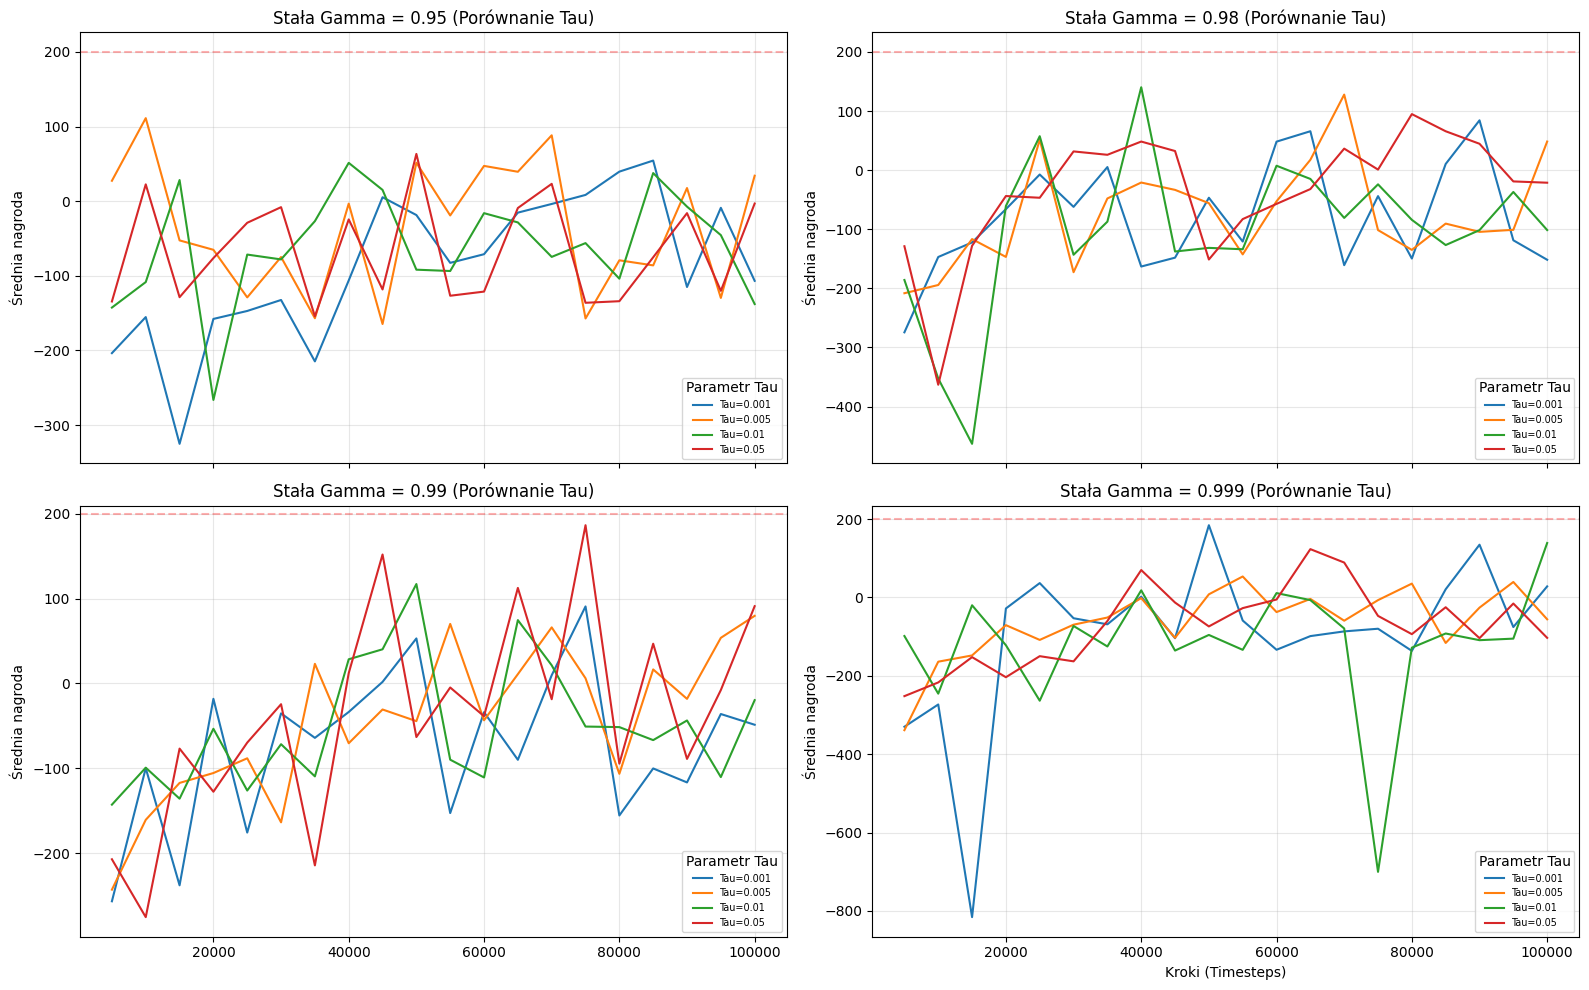

In [ ]:
### Porównanie wpływu Tau dla poszczególnych wartości Gamma - Poprawione
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for i, g_cel in enumerate(wartosci_gamma):
    ax = axes[i]
    # Szukamy kluczy, które zaczynają się dokładnie od danej wartości Gamma
    prefix = f"Gamma={g_cel}, "

    for nazwa, dane in wyniki_nowego_tuningu.items():
        if nazwa.startswith(prefix):
            # Wyciągamy samą wartość Tau do legendy
            tau_label = nazwa.split(", ")[1]
            ax.plot(dane['kroki'], dane['srednie_nagrody'], label=tau_label)

    ax.set_title(f"Stała Gamma = {g_cel} (Porównanie Tau)")
    ax.set_ylabel("Średnia nagroda")
    ax.axhline(y=200, color='r', linestyle='--', alpha=0.3)
    ax.legend(title="Parametr Tau", fontsize='x-small')
    ax.grid(True, alpha=0.3)

plt.xlabel("Kroki (Timesteps)")
plt.tight_layout()
plt.show()

## Optymalizacja eksploracji

In [ ]:


# Parametry bazowe
NAJLEPSZY_LR = 0.01
NAJLEPSZY_BATCH = 32
najlepsze_gamma=0.999
najlepsze_tau=0.001

# Parametry do testu 3D

eksploracja_frac = [0.05, 0.1, 0.15,0.2]
eksploracja_final=[0.001, 0.05, 0.01,0.1]

wyniki_3d = []

kombinacje = list(itertools.product(eksploracja_frac, eksploracja_final))
print(f"Rozpoczynam rozszerzony fine-tuning (łącznie {len(kombinacje)} kombinacji)... ")

for i, (e, f) in enumerate(kombinacje):
    konfiguracja = f"frac={e}, final={f}"
    print(f"[{i+1}/{len(kombinacje)}] Testuję: {konfiguracja}")

    sciezka = f"./logi_3d_{e}_{f}/"
    os.makedirs(sciezka, exist_ok=True)

    env_n = Monitor(gym.make("LunarLander-v3"), sciezka)
    eval_env_n = gym.make("LunarLander-v3")
    eval_callback = EvalCallback(eval_env_n, log_path=sciezka, eval_freq=5000, verbose=0)

    model = DQN(
        "MlpPolicy",
        env_n,
        gamma=najlepsze_gamma,
        tau=najlepsze_tau,
        learning_rate=NAJLEPSZY_LR,
        batch_size=NAJLEPSZY_BATCH,
        verbose=0,
        exploration_fraction=e,
        exploration_final_eps=f
    )

    model.learn(total_timesteps=100000, callback=eval_callback)

    # Obliczanie SKUMULOWANEJ nagrody ze wszystkich etapów ewaluacji
    dane = np.load(os.path.join(sciezka, "evaluations.npz"))
    nagroda = np.mean(dane['results'], axis=1)

    wyniki_3d.append({
        'frac': g,
        'final': t,
        'reward': nagroda
    })

print("Tuning zakończony!")

Rozpoczynam rozszerzony fine-tuning (łącznie 16 kombinacji)... 
[1/16] Testuję: frac=0.05, final=0.001


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


[2/16] Testuję: frac=0.05, final=0.05
[3/16] Testuję: frac=0.05, final=0.01
[4/16] Testuję: frac=0.05, final=0.1
[5/16] Testuję: frac=0.1, final=0.001
[6/16] Testuję: frac=0.1, final=0.05
[7/16] Testuję: frac=0.1, final=0.01
[8/16] Testuję: frac=0.1, final=0.1
[9/16] Testuję: frac=0.15, final=0.001
[10/16] Testuję: frac=0.15, final=0.05
[11/16] Testuję: frac=0.15, final=0.01
[12/16] Testuję: frac=0.15, final=0.1
[13/16] Testuję: frac=0.2, final=0.001
[14/16] Testuję: frac=0.2, final=0.05
[15/16] Testuję: frac=0.2, final=0.01
[16/16] Testuję: frac=0.2, final=0.1
Tuning zakończony!


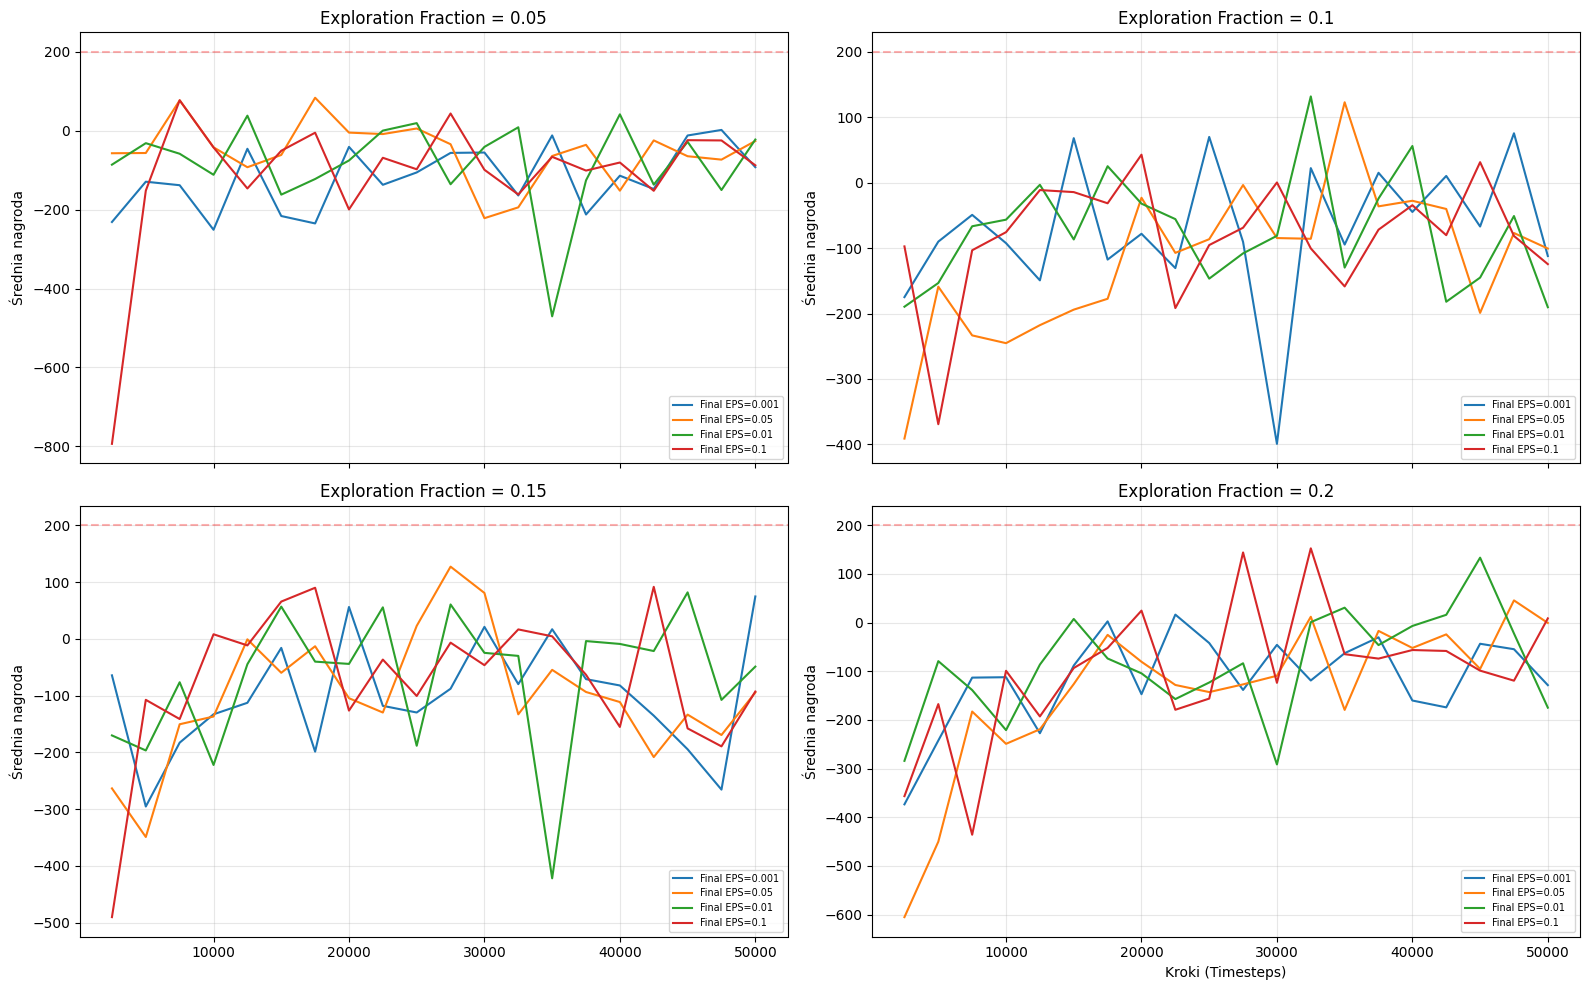

In [ ]:


# Przygotowanie danych do wykresów z wynikami eksploracji
# Grupujemy wyniki według 'frac' (exploration_fraction)
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

# Pobieramy unikalne wartości frac użyte w pętli
unique_fracs = [0.05, 0.1, 0.15, 0.2]

for i, frac_val in enumerate(unique_fracs):
    ax = axes[i]
    # Szukamy wyników w liście wyniki_3d (zapisanej w poprzedniej komórce)
    # Uwaga: w poprzedniej komórce był błąd zapisu do słownika (użyto g i t zamiast e i f)
    # Naprawimy to tutaj, iterując po wynikach chronologicznie zgodnie z kolejnością testów

    for idx, config_result in enumerate(wyniki_3d):
        # Obliczamy który to 'frac' na podstawie indeksu (pętla miała 16 iteracji, 4 per frac)
        current_frac_idx = idx // 4
        current_final_idx = idx % 4

        if current_frac_idx == i:
            label_final = eksploracja_final[current_final_idx]
            # Zakładamy, że os x to kroki ewaluacji (co 2500)
            steps = np.arange(2500, 50001, 2500)
            ax.plot(steps, config_result['reward'], label=f"Final EPS={label_final}")

    ax.set_title(f"Exploration Fraction = {frac_val}")
    ax.set_ylabel("Średnia nagroda")
    ax.axhline(y=200, color='r', linestyle='--', alpha=0.3)
    ax.legend(fontsize='x-small')
    ax.grid(True, alpha=0.3)

plt.xlabel("Kroki (Timesteps)")
plt.tight_layout()
plt.show()

### Porównanie Exploration Fraction dla ustalonych wartości Final Epsilon

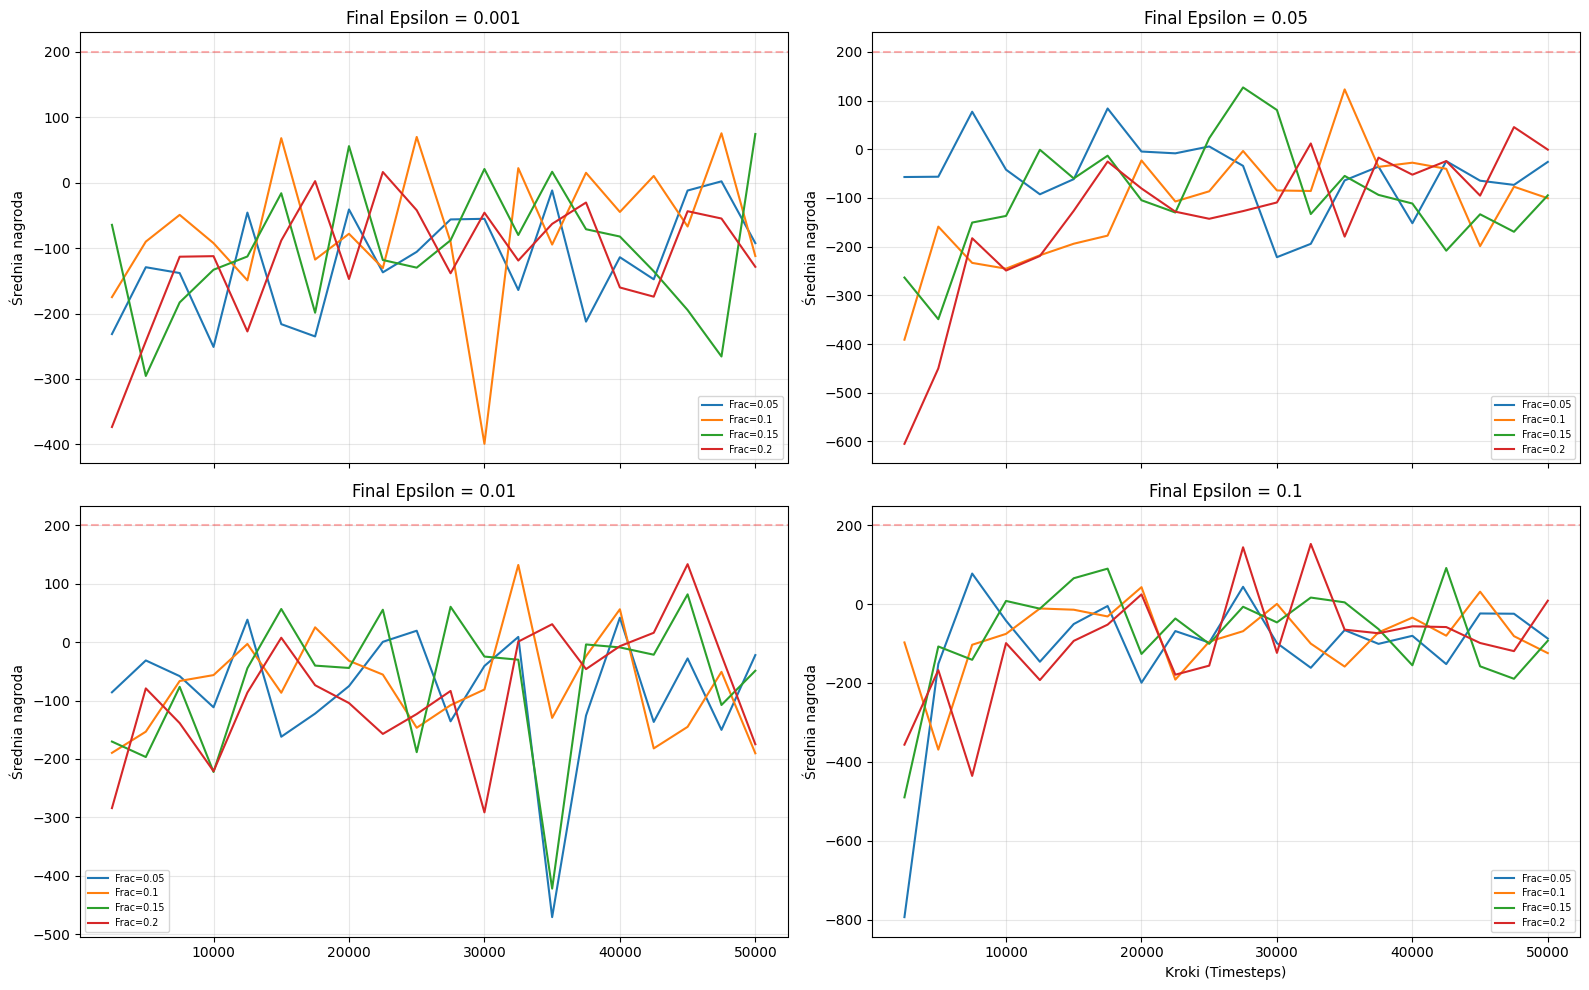

In [ ]:

# Parametry użyte w pętli
eksploracja_frac = [0.05, 0.1, 0.15, 0.2]
eksploracja_final = [0.001, 0.05, 0.01, 0.1]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for i, final_eps in enumerate(eksploracja_final):
    ax = axes[i]

    for idx, config_result in enumerate(wyniki_3d):
        # W strukturze wyniki_3d:
        # idx % 4 to indeks final_eps
        # idx // 4 to indeks frac
        current_final_idx = idx % 4
        current_frac_idx = idx // 4

        if current_final_idx == i:
            label_frac = eksploracja_frac[current_frac_idx]
            steps = np.arange(2500, 50001, 2500)
            ax.plot(steps, config_result['reward'], label=f"Frac={label_frac}")

    ax.set_title(f"Final Epsilon = {final_eps}")
    ax.set_ylabel("Średnia nagroda")
    ax.axhline(y=200, color='r', linestyle='--', alpha=0.3)
    ax.legend(fontsize='x-small')
    ax.grid(True, alpha=0.3)

plt.xlabel("Kroki (Timesteps)")
plt.tight_layout()
plt.show()

### Finalny Trening DQN - Najlepsze Parametry

In [ ]:


# Najlepsze parametry wyłonione w testach
BEST_LR = 0.001
BEST_BATCH = 16
BEST_GAMMA = 0.98
BEST_TAU = 0.01
BEST_FRAC = 0.1
BEST_FINAL_EPS = 0.05

log_dir_final = "./dqn_final_results/"
os.makedirs(log_dir_final, exist_ok=True)

train_env = Monitor(gym.make("LunarLander-v3"), log_dir_final)
eval_env = gym.make("LunarLander-v3")

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=log_dir_final,
    log_path=log_dir_final,
    eval_freq=5000,
    n_eval_episodes=10,
    deterministic=True
)

final_dqn_model = DQN(
    "MlpPolicy",
    train_env,
    learning_rate=BEST_LR,
    batch_size=BEST_BATCH,
    gamma=BEST_GAMMA,
    tau=BEST_TAU,
    exploration_fraction=BEST_FRAC,
    exploration_final_eps=BEST_FINAL_EPS,
    verbose=0
)

print("Rozpoczynam finalny trening DQN (200 000 kroków)... ")
final_dqn_model.learn(total_timesteps=200000, callback=eval_callback)
final_dqn_model.save("dqn_lunar_lander_final")
print("Trening zakończony! Model zapisany.")

Rozpoczynam finalny trening DQN (200 000 kroków)... 
Eval num_timesteps=5000, episode_reward=-234.49 +/- 24.99
Episode length: 862.20 +/- 276.86
New best mean reward!
Eval num_timesteps=10000, episode_reward=-343.60 +/- 228.03
Episode length: 683.20 +/- 290.32
Eval num_timesteps=15000, episode_reward=-299.29 +/- 141.45
Episode length: 355.90 +/- 219.37
Eval num_timesteps=20000, episode_reward=-403.02 +/- 51.87
Episode length: 256.10 +/- 68.31
Eval num_timesteps=25000, episode_reward=-39.94 +/- 173.68
Episode length: 489.70 +/- 260.40
New best mean reward!
Eval num_timesteps=30000, episode_reward=-48.75 +/- 240.77
Episode length: 361.00 +/- 81.35
Eval num_timesteps=35000, episode_reward=-14.49 +/- 169.80
Episode length: 464.60 +/- 203.97
New best mean reward!
Eval num_timesteps=40000, episode_reward=-43.97 +/- 123.73
Episode length: 460.60 +/- 275.21
Eval num_timesteps=45000, episode_reward=102.14 +/- 188.78
Episode length: 387.80 +/- 210.48
New best mean reward!
Eval num_timesteps=5000

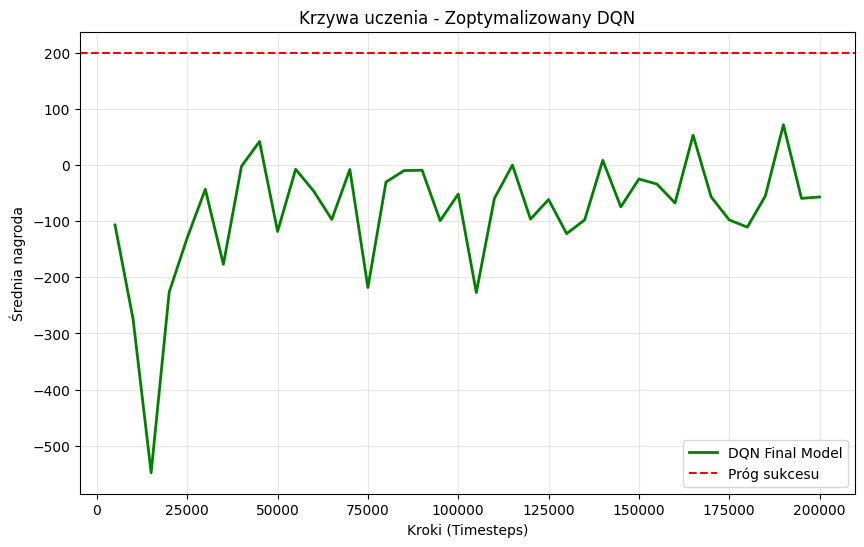

In [ ]:
# Wizualizacja krzywej uczenia finalnego modelu
data = np.load(os.path.join(log_dir_final, "evaluations.npz"))
timesteps = data['timesteps']
results = data['results']
mean_rewards = np.mean(results, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(timesteps, mean_rewards, label='DQN Final Model', color='green', linewidth=2)
plt.axhline(y=200, color='r', linestyle='--', label='Próg sukcesu')
plt.title("Krzywa uczenia - Zoptymalizowany DQN")
plt.xlabel("Kroki (Timesteps)")
plt.ylabel("Średnia nagroda")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#PPO

In [ ]:
### przykładowy trening PPO (masa jest policy gradientów, więc wzięłam ten)
# Tworzenie środowiska treningowego
train_env = gym.make("LunarLander-v3")

# Inicjalizacja algorytmu PPO
model = PPO(
    "MlpPolicy",
    train_env,
    verbose=1,            # Pokazuje statystyki w konsoli
    learning_rate=3e-4,   # Standardowy, bezpieczny krok uczenia dla PPO
    n_steps=1024,         # Jak wiele kroków zbiera przed jedną aktualizacją sieci
    batch_size=64,        # Rozmiar paczki danych do treningu sieci
    n_epochs=4,           # Ile razy sieć analizuje tę samą paczkę danych
    gamma=0.999           # Współczynnik dyskontowania (jak ważna jest przyszłość)
)

# Rozpoczęcie procesu uczenia (50 000 kroków)
print("Rozpoczynam trenowanie sieci za pomocą PPO (Policy Gradient)...")
model.learn(total_timesteps=50000)
print("Trening zakończony!")

# Tworzenie środowiska testowego z nagrywaniem wideo
test_env = gym.make("LunarLander-v3", render_mode="rgb_array")
test_env = RecordVideo(test_env, video_folder="ppo_lunar_lander", episode_trigger=lambda ep: True)

# Testowanie i zapis ostatecznego przejazdu
obs, info = test_env.reset()
done = False

while not done:
    # Wykorzystujemy nauczoną politykę
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = test_env.step(action)
    done = terminated or truncated

test_env.close()
print("Wideo z agentem PPO zostało wygenerowane!")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Rozpoczynam trenowanie sieci za pomocą PPO (Policy Gradient)...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 98.4     |
|    ep_rew_mean     | -145     |
| time/              |          |
|    fps             | 350      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 1024     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 98.2         |
|    ep_rew_mean          | -162         |
| time/                   |              |
|    fps                  | 456          |
|    iterations           | 2            |
|    time_elapsed         | 4            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0008980251 |
|    clip_fraction        | 0

NameError: name 'RecordVideo' is not defined

In [ ]:
# wideo z PPO
video_dir = "ppo_lunar_lander"
mp4_files = [f for f in os.listdir(video_dir) if f.endswith('.mp4')]

if mp4_files:
    video_path = os.path.join(video_dir, mp4_files[0])
    print(f"Odtwarzam przejazd agenta wytrenowanego metodą Policy Gradient (PPO): {video_path}")
    display(Video(video_path, embed=True, width=600))
else:
    print("Nie znaleziono pliku wideo. Upewnij się, że komóka z treningiem PPO wykonała się pomyślnie.")

FileNotFoundError: [Errno 2] No such file or directory: 'ppo_lunar_lander'

In [ ]:
# teraz moja kolej - Maciek

In [ ]:

# Instalujemy wszystko z pominięciem zależności, które się gryzą
!apt-get install -y swig
!pip install "gymnasium[box2d]"
!pip install stable-baselines3 --no-deps
!pip install shimmy

import os
import numpy as np
import gymnasium as gym
from stable_baselines3 import PPO, DQN
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt

print("Biblioteki załadowane. Możesz pracować.")

# Setup środowiska
env = Monitor(gym.make("LunarLander-v3"))


#Wczytanie gotowych modeli
PPO_MODEL_PATH = "ppo_lunar_lander.zip"
DQN_MODEL_PATH = "dqn_lunar_lander.zip"

model_ppo = None
model_dqn = None

print("\n--- Próba załadowania zapisanych modeli ---")
try:
    if os.path.exists(PPO_MODEL_PATH):
        model_ppo = PPO.load(PPO_MODEL_PATH, env=env)
        print("Model PPO załadowany! Możesz robić fine-tuning lub testy.")
    else:
        print(f"Brak pliku {PPO_MODEL_PATH}. (Jeśli trenujesz od zera, zignoruj to).")

    if os.path.exists(DQN_MODEL_PATH):
        model_dqn = DQN.load(DQN_MODEL_PATH, env=env)
        print("Model DQN załadowany!")
    else:
        print(f" Brak pliku {DQN_MODEL_PATH}.")

except Exception as e:
    print(f" Wystąpił błąd podczas ładowania modeli: {e}")

print("\n--- Setup zakończony. Możesz działać dalej! ---")



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  swig4.0
Suggested packages:
  swig-doc swig-examples swig4.0-examples swig4.0-doc
The following NEW packages will be installed:
  swig swig4.0
0 upgraded, 2 newly installed, 0 to remove and 3 not upgraded.
Need to get 1,116 kB of archives.
After this operation, 5,542 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig4.0 amd64 4.0.2-1ubuntu1 [1,110 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig all 4.0.2-1ubuntu1 [5,632 B]
Fetched 1,116 kB in 0s (7,395 kB/s)
Selecting previously unselected package swig4.0.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../swig4.0_4.0.2-1ubuntu1_amd64.deb ...
Unpacking swig4.0 (4.0.2-1ubuntu1) ...
Selecting previously unselected package swig.
Preparing to unpack .../swig_4.0.2-1ubun

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tz

In [ ]:
import os
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

print("--- Rozpoczynamy zoptymalizowany trening PPO ---")

# folder do wykresów
log_dir = "./ppo_logs_final/"
os.makedirs(log_dir, exist_ok=True)

# środowisko do ewaluacji
eval_env = Monitor(gym.make("LunarLander-v3"))

# EvalCallback
eval_callback = EvalCallback(eval_env,
                             best_model_save_path=log_dir,
                             log_path=log_dir,
                             eval_freq=5000,
                             n_eval_episodes=5,
                             deterministic=True,
                             render=False)

# PPO pro
model_ppo_pro = PPO("MlpPolicy", env,
                    learning_rate=0.0003,
                    n_steps=1024,
                    batch_size=64,
                    n_epochs=10,
                    gamma=0.99,
                    gae_lambda=0.98,
                    clip_range=0.2,
                    verbose=0)

# właściwy trening
model_ppo_pro.learn(total_timesteps=200000, callback=eval_callback)

# ostateczny model
model_ppo_pro.save("ppo_lunar_lander")
print(" Trening zakończony!")
print(" Logi do wykresów zapisane w folderze: ./ppo_logs_final/")
print(" Ostateczny model zapisany jako: ppo_lunar_lander.zip")

--- Rozpoczynamy zoptymalizowany trening PPO ---
Eval num_timesteps=5000, episode_reward=-408.30 +/- 256.15
Episode length: 115.00 +/- 50.67
New best mean reward!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Eval num_timesteps=10000, episode_reward=-297.15 +/- 91.91
Episode length: 94.80 +/- 25.42
New best mean reward!
Eval num_timesteps=15000, episode_reward=-2094.53 +/- 2011.22
Episode length: 244.80 +/- 140.15
Eval num_timesteps=20000, episode_reward=-443.57 +/- 356.13
Episode length: 190.00 +/- 76.53
Eval num_timesteps=25000, episode_reward=-472.83 +/- 316.92
Episode length: 249.40 +/- 77.76
Eval num_timesteps=30000, episode_reward=-273.43 +/- 105.43
Episode length: 265.20 +/- 96.80
New best mean reward!
Eval num_timesteps=35000, episode_reward=-322.83 +/- 128.48
Episode length: 309.20 +/- 152.99
Eval num_timesteps=40000, episode_reward=-1184.69 +/- 264.75
Episode length: 678.80 +/- 101.89
Eval num_timesteps=45000, episode_reward=-419.75 +/- 121.02
Episode length: 369.60 +/- 83.63
Eval num_timesteps=50000, episode_reward=-1172.07 +/- 447.17
Episode length: 348.60 +/- 96.02
Eval num_timesteps=55000, episode_reward=-501.05 +/- 245.51
Episode length: 513.80 +/- 257.29
Eval num_timesteps=6

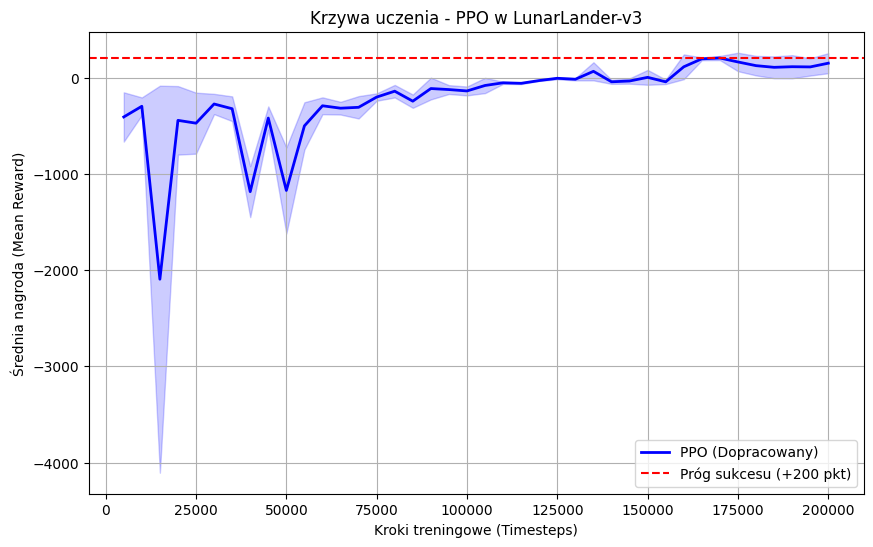

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Ścieżka do logów PPO z EvalCallback
ppo_log_path = "./ppo_logs_final/evaluations.npz"

if os.path.exists(ppo_log_path):
    data = np.load(ppo_log_path)
    timesteps = data["timesteps"]
    mean_rewards = np.mean(data["results"], axis=1)
    std_rewards = np.std(data["results"], axis=1)

    # Rysowanie wykresu
    plt.figure(figsize=(10, 6))
    plt.plot(timesteps, mean_rewards, label="PPO (Dopracowany)", color='blue', linewidth=2)

    # cien (wariancję)
    plt.fill_between(timesteps, mean_rewards - std_rewards, mean_rewards + std_rewards, color='blue', alpha=0.2)

    # próg sukcesu
    plt.axhline(y=200, color='red', linestyle='--', label="Próg sukcesu (+200 pkt)")

    plt.title("Krzywa uczenia - PPO w LunarLander-v3")
    plt.xlabel("Kroki treningowe (Timesteps)")
    plt.ylabel("Średnia nagroda (Mean Reward)")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Nie znaleziono pliku z logami! Sprawdź ścieżkę.")

In [ ]:
# to mam juz mam w plikach wiec pokazac tylkko
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.vec_env import DummyVecEnv, VecVideoRecorder
import gymnasium as gym

print("Nagrywanie ostatecznego przelotu PPO...")

# Tworzymy środowisko do nagrywania
video_folder = "lunar_lander_videos_final"
os.makedirs(video_folder, exist_ok=True)

# Opakowujemy środowisko w VecVideoRecorder
eval_env_vid = DummyVecEnv([lambda: gym.make("LunarLander-v3", render_mode="rgb_array")])
eval_env_vid = VecVideoRecorder(eval_env_vid, video_folder,
                                record_video_trigger=lambda x: x == 0, video_length=1000,
                                name_prefix="ppo_pro_agent")

obs = eval_env_vid.reset()
for _ in range(1000):
    action, _states = model_ppo_pro.predict(obs, deterministic=True)
    obs, _, done, _ = eval_env_vid.step(action)
    if done:
        break

eval_env_vid.close()
print(f"Wideo zapisane w folderze: {video_folder}")

Nagrywanie ostatecznego przelotu PPO...


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Moviepy - Building video /content/lunar_lander_videos_final/ppo_pro_agent-step-0-to-step-1000.mp4.
Moviepy - Writing video /content/lunar_lander_videos_final/ppo_pro_agent-step-0-to-step-1000.mp4



Moviepy - Done !
Moviepy - video ready /content/lunar_lander_videos_final/ppo_pro_agent-step-0-to-step-1000.mp4
Wideo zapisane w folderze: lunar_lander_videos_final


In [ ]:
# i tutaj juz jest do porownania(chyba)
# wiec to chyba na nastepne zajecia

import os
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

print("--- Szybki trening modelu bazowego (Baseline) dla logów ---")

# 1. Folder docelowy na logi baseline'u, którego szuka Twój kod z wykresem
baseline_log_dir = "./ppo_logs/PPO_Baseline/"
os.makedirs(baseline_log_dir, exist_ok=True)

# 2. Środowisko testowe z Monitorem
eval_env_baseline = Monitor(gym.make("LunarLander-v3"))

# 3. Konfiguracja EvalCallback (żeby wypluł nam upragniony plik .npz)
eval_callback_baseline = EvalCallback(eval_env_baseline,
                                      best_model_save_path=baseline_log_dir,
                                      log_path=baseline_log_dir,
                                      eval_freq=5000,
                                      n_eval_episodes=5,
                                      deterministic=True,
                                      render=False)

# 4. Tworzymy środowisko i model PPO NA CAŁKOWICIE DOMYŚLNYCH PARAMETRACH
env_baseline = Monitor(gym.make("LunarLander-v3"))
model_baseline = PPO("MlpPolicy", env_baseline, verbose=0)

# 5. Odpalamy stary, krótki trening z podpiętym logowaniem
print("Trenuję bazowe PPO... Idź zrób herbatę, to zaraz się skończy.")
model_baseline.learn(total_timesteps=50000, callback=eval_callback_baseline)

print("✅ Trening bazowy zakończony! Plik evaluations.npz został wygenerowany w folderze PPO_Baseline.")

--- Szybki trening modelu bazowego (Baseline) dla logów ---
Trenuję bazowe PPO... Idź zrób herbatę, to zaraz się skończy.
Eval num_timesteps=5000, episode_reward=-122.46 +/- 59.05
Episode length: 167.80 +/- 133.80
New best mean reward!
Eval num_timesteps=10000, episode_reward=-102.23 +/- 35.12
Episode length: 326.60 +/- 221.19
New best mean reward!
Eval num_timesteps=15000, episode_reward=-1509.98 +/- 781.49
Episode length: 297.40 +/- 100.46
Eval num_timesteps=20000, episode_reward=-2319.19 +/- 688.17
Episode length: 385.40 +/- 47.03
Eval num_timesteps=25000, episode_reward=-671.54 +/- 161.49
Episode length: 325.60 +/- 53.98
Eval num_timesteps=30000, episode_reward=-1443.69 +/- 933.14
Episode length: 434.60 +/- 106.84
Eval num_timesteps=35000, episode_reward=-487.40 +/- 225.13
Episode length: 471.40 +/- 196.81
Eval num_timesteps=40000, episode_reward=-804.07 +/- 419.82
Episode length: 519.60 +/- 219.94
Eval num_timesteps=45000, episode_reward=-738.85 +/- 418.41
Episode length: 456.40 +

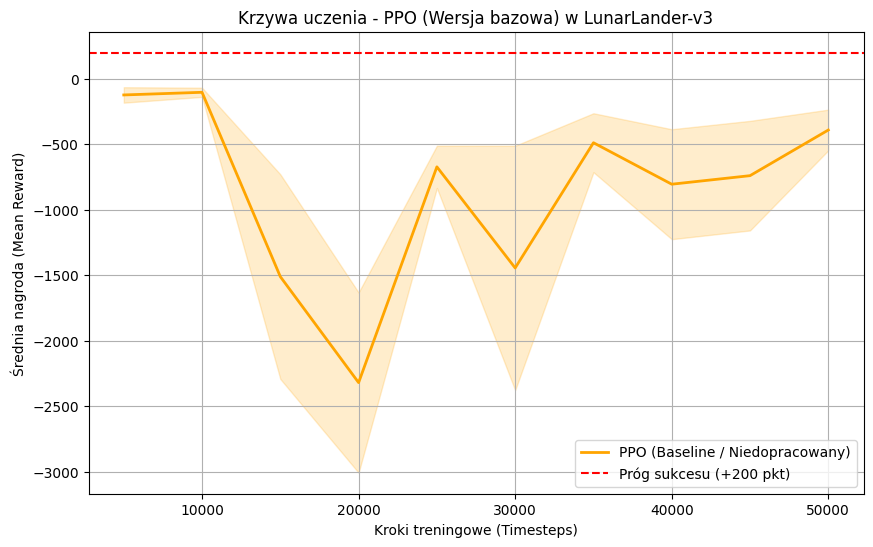

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import os

baseline_log_path = "./ppo_logs/PPO_Baseline/evaluations.npz"

if os.path.exists(baseline_log_path):
    data = np.load(baseline_log_path)
    timesteps = data["timesteps"]
    mean_rewards = np.mean(data["results"], axis=1)
    std_rewards = np.std(data["results"], axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(timesteps, mean_rewards, label="PPO (Baseline / Niedopracowany)", color='orange', linewidth=2)
    plt.fill_between(timesteps, mean_rewards - std_rewards, mean_rewards + std_rewards, color='orange', alpha=0.2)
    plt.axhline(y=200, color='red', linestyle='--', label="Próg sukcesu (+200 pkt)")

    plt.title("Krzywa uczenia - PPO (Wersja bazowa) w LunarLander-v3")
    plt.xlabel("Kroki treningowe (Timesteps)")
    plt.ylabel("Średnia nagroda (Mean Reward)")
    plt.legend()
    plt.grid(True)

    # Wyświetla wykres pod komórką
    plt.show()
else:
    print(f"❌ Nie znaleziono pliku: {baseline_log_path}")

#A2C

A2C (Advantage Actor-Critic [w wersji synchronicznej](https://arxiv.org/pdf/1602.01783)) to algorytm [uczenia ze wzmacnianiem](https://www.ibm.com/think/topics/reinforcement-learning) rodzaju policy gradient.

Działanie polega na dwóch osobnych sieciach, nazwanych aktor i krytyk, które wymieniają się informacją - aktor przyjmuje dane i oddaje działanie (akcję, stan), a krytyk przyjmuje działanie (akcję, stan) i oddaje ocenę. Aktor przy pomocy funkcji advantage, która jest różnicą między wartością oczekiwaną następnych nagród a oceną oddaną przez krytyka wylicza prawdopodobieństwo wywołania konkretnego (ocenianego) działania (stanu) w następnym kroku treningu.


Ważne jest, że większość wartości na których podstawie są podejmowane decyzje o zmianie prawdopodobieństwa akcji są estymowane (w tym przypadku za pomocą tzw. funkcji temporal difference).

https://stable-baselines3.readthedocs.io/en/master/common/logger.html





In [ ]:
import gymnasium as gym
from stable_baselines3 import A2C
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor
import os

log_dir_a2c_eval = "./logs_a2c_eval_new/"
os.makedirs(log_dir_a2c_eval, exist_ok=True)

env = Monitor(gym.make("LunarLander-v3"))
# multilayer perceptron
model = A2C("MlpPolicy", env, verbose=1)

env_eval = Monitor(gym.make("LunarLander-v3"))
eval_callback_a2c = EvalCallback(
    env_eval,
    eval_freq=5000,
    n_eval_episodes=5,
    deterministic=True,
    render=False,
    log_path=log_dir_a2c_eval,
    best_model_save_path=log_dir_a2c_eval
)

model.learn(total_timesteps=50000, callback = eval_callback_a2c)

# model.save("a2c")

env.close()

Using cuda device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 92.5     |
|    ep_rew_mean        | -274     |
| time/                 |          |
|    fps                | 253      |
|    iterations         | 100      |
|    time_elapsed       | 1        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -1.3     |
|    explained_variance | 0.00824  |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | -3.78    |
|    value_loss         | 7.39     |
------------------------------------
-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 126       |
|    ep_rew_mean        | -338      |
| time/                 |           |
|    fps                | 319       |
|    iterations         | 200       |
|    time_elapsed       | 3         |
|    total_timesteps    | 1000      |
| train/                |    

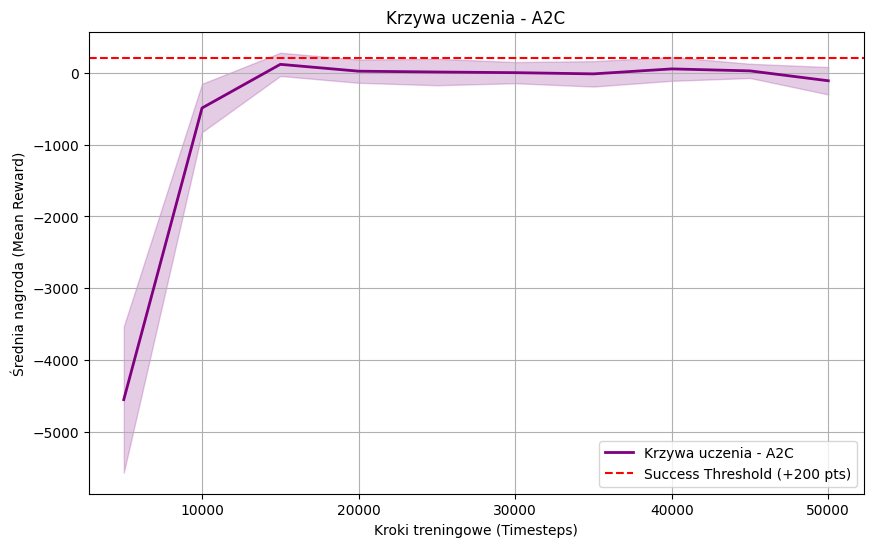

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

a2c_log_path = "./logs_a2c_eval_new/evaluations.npz"

if os.path.exists(a2c_log_path):
    data = np.load(a2c_log_path)
    timesteps = data["timesteps"]
    mean_rewards = np.mean(data["results"], axis=1)
    std_rewards = np.std(data["results"], axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(timesteps, mean_rewards, label="Krzywa uczenia - A2C", color='purple', linewidth=2)

    plt.fill_between(timesteps, mean_rewards - std_rewards, mean_rewards + std_rewards, color='purple', alpha=0.2) # wariancja / odchylenie

    plt.axhline(y=200, color='red', linestyle='--', label="Próg sukcesu (+200 pkt)")

    plt.title("Krzywa uczenia - A2C")
    plt.xlabel("Kroki treningowe (Timesteps)")
    plt.ylabel("Średnia nagroda (Mean Reward)")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print(f"Error: Evaluation log file not found at {a2c_log_path}")


Na wykresie widać szybką stabilizację nagrody , ale jednak bardziej na małym, pozytywnym poziomie niż negatywnym.

## Analiza długości epizodów A2C

Oprócz nagród, warto również monitorować długość epizodów. Długość epizodu może wskazywać, czy agent uczy się efektywniej kończyć zadania (np. lądować szybciej i precyzyjniej), czy też epizody są przerywane z powodu błędów (np. rozbicia się, wyjścia poza obszar).

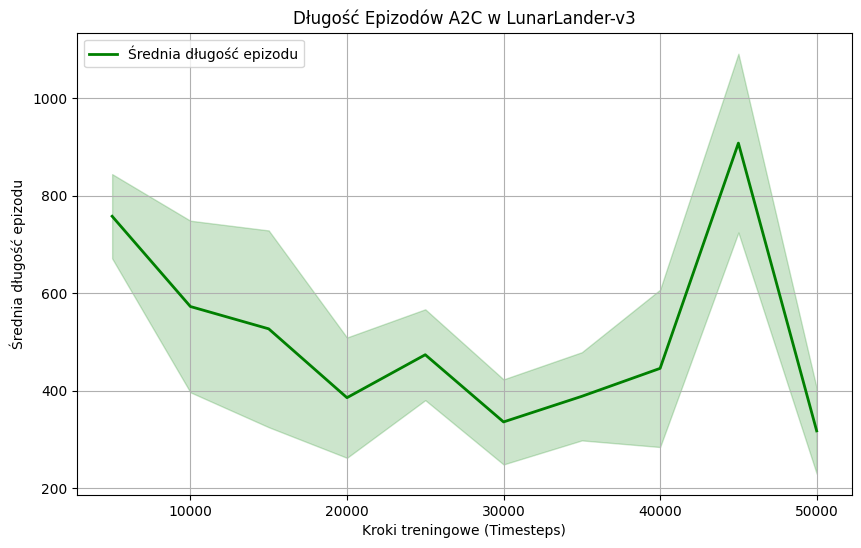

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

a2c_log_path = "./logs_a2c_eval_new/evaluations.npz"

if os.path.exists(a2c_log_path):
    data = np.load(a2c_log_path)
    timesteps = data["timesteps"]

    # Sprawdź, czy 'ep_lengths' jest dostępny w pliku npz
    if 'ep_lengths' in data:
        episode_lengths = data['ep_lengths']
        mean_episode_length = np.mean(episode_lengths, axis=1)
        std_episode_length = np.std(episode_lengths, axis=1)

        plt.figure(figsize=(10, 6))
        plt.plot(timesteps, mean_episode_length, label="Średnia długość epizodu", color='green', linewidth=2)
        plt.fill_between(timesteps, mean_episode_length - std_episode_length, mean_episode_length + std_episode_length, color='green', alpha=0.2)

        plt.title("Długość Epizodów A2C w LunarLander-v3")
        plt.xlabel("Kroki treningowe (Timesteps)")
        plt.ylabel("Średnia długość epizodu")
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("Brak danych o długościach epizodów ('ep_lengths') w pliku evaluations.npz.")
else:
    print(f"Error: Evaluation log file not found at {a2c_log_path}")

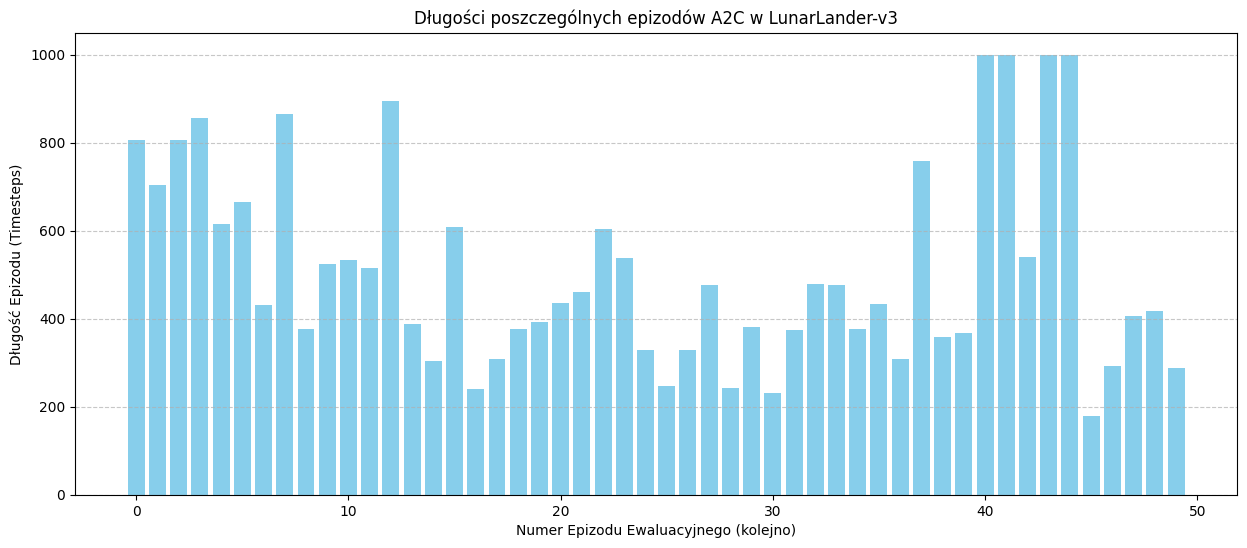

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

a2c_log_path = "./logs_a2c_eval_new/evaluations.npz"

if os.path.exists(a2c_log_path):
    data = np.load(a2c_log_path)

    if 'ep_lengths' in data:
        # Wczytaj wszystkie długości epizodów
        episode_lengths_all = data['ep_lengths']
        # Spłaszcz tablicę, aby uzyskać wszystkie pojedyncze długości epizodów
        flattened_episode_lengths = episode_lengths_all.flatten()

        plt.figure(figsize=(15, 6))
        # Tworzymy wykres słupkowy, gdzie każdy słupek to długość pojedynczego epizodu
        plt.bar(range(len(flattened_episode_lengths)), flattened_episode_lengths, color='skyblue')

        plt.title("Długości poszczególnych epizodów A2C w LunarLander-v3")
        plt.xlabel("Numer Epizodu Ewaluacyjnego (kolejno)")
        plt.ylabel("Długość Epizodu (Timesteps)")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
    else:
        print("Brak danych o długościach epizodów ('ep_lengths') w pliku evaluations.npz.")
else:
    print(f"Error: Evaluation log file not found at {a2c_log_path}")

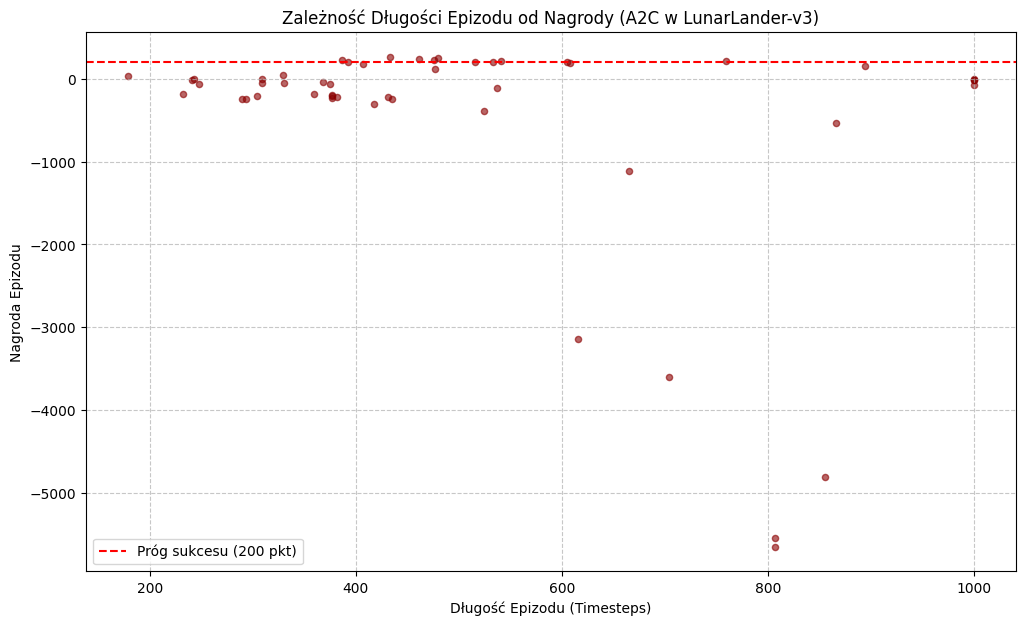

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

a2c_log_path = "./logs_a2c_eval_new/evaluations.npz"

if os.path.exists(a2c_log_path):
    data = np.load(a2c_log_path)

    if 'ep_lengths' in data and 'results' in data:
        # Wczytaj i spłaszcz wszystkie długości epizodów
        episode_lengths_all = data['ep_lengths']
        flattened_episode_lengths = episode_lengths_all.flatten()

        # Wczytaj i spłaszcz wszystkie nagrody (results) - muszą odpowiadać długościom
        all_rewards = data['results']
        flattened_rewards = all_rewards.flatten()

        # Sprawdzenie, czy liczby elementów się zgadzają
        if len(flattened_episode_lengths) != len(flattened_rewards):
            print("Błąd: Liczba długości epizodów nie zgadza się z liczbą nagród.")
        else:
            plt.figure(figsize=(12, 7))
            plt.scatter(flattened_episode_lengths, flattened_rewards, alpha=0.6, color='darkred', s=20) # s to rozmiar punktu

            plt.title("Zależność Długości Epizodu od Nagrody (A2C w LunarLander-v3)")
            plt.xlabel("Długość Epizodu (Timesteps)")
            plt.ylabel("Nagroda Epizodu")
            plt.axhline(y=200, color='red', linestyle='--', label='Próg sukcesu (200 pkt)')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.legend()
            plt.show()
    else:
        print("Brak danych o długościach epizodów ('ep_lengths') lub nagrodach ('results') w pliku evaluations.npz.")
else:
    print(f"Error: Evaluation log file not found at {a2c_log_path}")

Im dłużej trwał epizod, tym większą karę (ujemną nagrodę) otrzymywał aktor.
